In [6]:
import pandas as pd
import re
import string

# Load dataset
df = pd.read_csv("../data/fake_reviews.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())


# Text cleaning function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text


# Apply cleaning
df["clean_text"] = df["text_"].apply(clean_text)


# Display result
print("\nOriginal Review:")
print(df["text_"].iloc[0])

print("\nCleaned Review:")
print(df["clean_text"].iloc[0])

print("\nMissing Values:")
print(df["clean_text"].isnull().sum())

Dataset loaded successfully!
Shape: (40432, 4)
Columns: ['category', 'rating', 'label', 'text_']

Original Review:
Love this!  Well made, sturdy, and very comfortable.  I love it!Very pretty

Cleaned Review:
love this well made sturdy and very comfortable i love itvery pretty

Missing Values:
0


In [8]:
# TF-IDF Vectorization

from sklearn.feature_extraction.text import TfidfVectorizer

# Convert labels to binary
df["label_binary"] = df["label"].map({
    "CG": 0,
    "OR": 1
})

# Create TF-IDF features
vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english"
)

X = vectorizer.fit_transform(df["clean_text"])
y = df["label_binary"]

print("TF-IDF Vectorization completed!")
print("X Shape:", X.shape)
print("Y Shape:", y.shape)

TF-IDF Vectorization completed!
X Shape: (40432, 10000)
Y Shape: (40432,)


In [9]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-Test Split Completed!")
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

Train-Test Split Completed!
X_train Shape: (32345, 10000)
X_test Shape: (8087, 10000)
y_train Shape: (32345,)
y_test Shape: (8087,)


In [10]:
# Model Training - Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Model")
print("Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Logistic Regression Model
Accuracy: 0.8633609496723136

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      4044
           1       0.85      0.88      0.87      4043

    accuracy                           0.86      8087
   macro avg       0.86      0.86      0.86      8087
weighted avg       0.86      0.86      0.86      8087


Confusion Matrix:
[[3430  614]
 [ 491 3552]]


In [11]:
# Model Training - Naive Bayes

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
nb_model = MultinomialNB()

# Train model
nb_model.fit(X_train, y_train)

# Predict test data
y_pred_nb = nb_model.predict(X_test)

# Accuracy
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Model")
print("Accuracy:", accuracy_nb)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

Naive Bayes Model
Accuracy: 0.8519846667491034

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      4044
           1       0.88      0.81      0.85      4043

    accuracy                           0.85      8087
   macro avg       0.85      0.85      0.85      8087
weighted avg       0.85      0.85      0.85      8087


Confusion Matrix:
[[3602  442]
 [ 755 3288]]


In [12]:
# Model Training - Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)

# Predict test data
y_pred_rf = rf_model.predict(X_test)

# Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Model")
print("Accuracy:", accuracy_rf)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Model
Accuracy: 0.8422159020650427

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.85      4044
           1       0.87      0.81      0.84      4043

    accuracy                           0.84      8087
   macro avg       0.84      0.84      0.84      8087
weighted avg       0.84      0.84      0.84      8087


Confusion Matrix:
[[3536  508]
 [ 768 3275]]


In [13]:
# Model Comparison

models = {
    "Logistic Regression": accuracy,
    "Naive Bayes": accuracy_nb,
    "Random Forest": accuracy_rf
}

print("Model Comparison")
print("-" * 30)

for name, acc in models.items():
    print(f"{name}: {acc:.4f} ({acc * 100:.2f}%)")

Model Comparison
------------------------------
Logistic Regression: 0.8634 (86.34%)
Naive Bayes: 0.8520 (85.20%)
Random Forest: 0.8422 (84.22%)


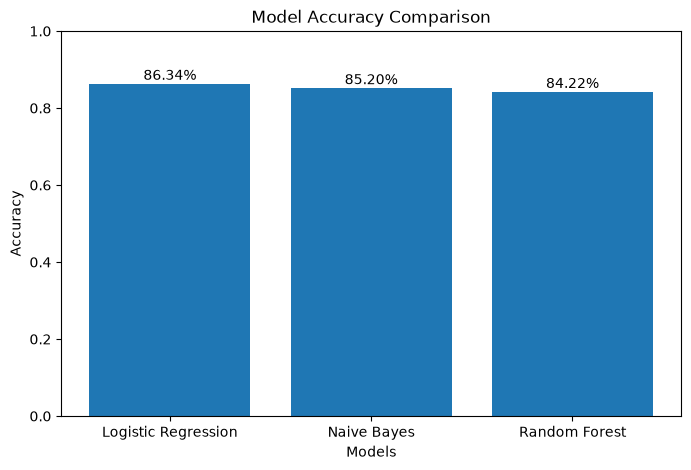

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(models.keys(), models.values())

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for i, value in enumerate(models.values()):
    plt.text(i, value + 0.01, f"{value:.2%}", ha="center")

plt.show()

In [15]:
# Model Selection
best_model = model

print("Best Model: Logistic Regression")
print("Accuracy:", accuracy)

Best Model: Logistic Regression
Accuracy: 0.8633609496723136


In [16]:
import joblib

# Save trained model
joblib.dump(best_model, "../src/fake_review_model.pkl")

# Save TF-IDF vectorizer
joblib.dump(vectorizer, "../src/tfidf_vectorizer.pkl")

print("Model and TF-IDF Vectorizer saved successfully!")

Model and TF-IDF Vectorizer saved successfully!
